#### GARCH vs LSTM Comparison

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

ftse = pd.read_csv('data/ftse_processed.csv', index_col='Date', parse_dates=True)
sp500 = pd.read_csv('data/sp500_processed.csv', index_col='Date', parse_dates=True)

ftse_clean = ftse.dropna(subset=['volatility_annualized']).copy()
sp500_clean = sp500.dropna(subset=['volatility_annualized']).copy()

print("FTSE clean:", ftse_clean.shape)
print("S&P 500 clean:", sp500_clean.shape)

FTSE clean: (2904, 8)
S&P 500 clean: (2890, 8)


In [3]:
#Recreate the exact same train/test split

SEQ_LENGTH = 21
TEST_RATIO = 0.2

def get_split_index(data_len, seq_length, test_ratio=0.2):
    # Matches the same logic used for LSTM sequence splitting
    usable_len = data_len - seq_length
    split_idx = int(usable_len * (1 - test_ratio))
    return split_idx + seq_length  # offset back to original data indexing

split_idx_ftse = get_split_index(len(ftse_clean), SEQ_LENGTH, TEST_RATIO)
split_idx_sp500 = get_split_index(len(sp500_clean), SEQ_LENGTH, TEST_RATIO)

print("FTSE split index:", split_idx_ftse, "of", len(ftse_clean))
print("S&P 500 split index:", split_idx_sp500, "of", len(sp500_clean))

FTSE split index: 2327 of 2904
S&P 500 split index: 2316 of 2890


In [4]:
#Refitting GARCH on training data only, then forecast forward

def garch_rolling_forecast(returns, split_idx, test_len):
    """
    Fits GARCH on training data, then produces one-step-ahead volatility 
    forecasts for each day in the test period, refitting as we roll forward
    (using only data available up to that point — no future leakage).
    """
    forecasts = []
    
    for i in range(test_len):
        # Use all data up to (but not including) the current test point
        train_data = returns.iloc[:split_idx + i] * 100
        
        model = arch_model(train_data, vol='Garch', p=1, q=1, dist='t')
        fitted = model.fit(disp='off')
        
        # Forecast 1 day ahead
        forecast = fitted.forecast(horizon=1)
        variance_forecast = forecast.variance.values[-1, 0]
        vol_forecast = np.sqrt(variance_forecast) / 100 * np.sqrt(252)  # annualize
        
        forecasts.append(vol_forecast)
        
        if (i + 1) % 100 == 0:
            print(f"  Forecasted {i+1}/{test_len} days...")
    
    return np.array(forecasts)

In [5]:
test_len_ftse = len(ftse_clean) - split_idx_ftse
test_len_sp500 = len(sp500_clean) - split_idx_sp500

print(f"Forecasting {test_len_ftse} days for FTSE...")
garch_forecast_ftse = garch_rolling_forecast(ftse_clean['log_return'], split_idx_ftse, test_len_ftse)

print(f"\nForecasting {test_len_sp500} days for S&P 500...")
garch_forecast_sp500 = garch_rolling_forecast(sp500_clean['log_return'], split_idx_sp500, test_len_sp500)

Forecasting 577 days for FTSE...
  Forecasted 100/577 days...
  Forecasted 200/577 days...
  Forecasted 300/577 days...
  Forecasted 400/577 days...
  Forecasted 500/577 days...

Forecasting 574 days for S&P 500...
  Forecasted 100/574 days...
  Forecasted 200/574 days...
  Forecasted 300/574 days...
  Forecasted 400/574 days...
  Forecasted 500/574 days...


In [6]:
#Evaluating GARCH out-of-sample

def evaluate_garch(forecast, actual_vol, split_idx, data_len):
    actual = actual_vol.iloc[split_idx:split_idx + len(forecast)].values
    
    rmse = np.sqrt(np.mean((forecast - actual) ** 2))
    mae = np.mean(np.abs(forecast - actual))
    
    print(f"GARCH Test RMSE: {rmse:.4f}")
    print(f"GARCH Test MAE: {mae:.4f}")
    
    return actual, rmse, mae

print("--- FTSE 100 GARCH Out-of-Sample Performance ---")
actual_garch_ftse, rmse_garch_ftse, mae_garch_ftse = evaluate_garch(
    garch_forecast_ftse, ftse_clean['volatility_annualized'], split_idx_ftse, len(ftse_clean)
)

print("\n--- S&P 500 GARCH Out-of-Sample Performance ---")
actual_garch_sp500, rmse_garch_sp500, mae_garch_sp500 = evaluate_garch(
    garch_forecast_sp500, sp500_clean['volatility_annualized'], split_idx_sp500, len(sp500_clean)
)

--- FTSE 100 GARCH Out-of-Sample Performance ---
GARCH Test RMSE: 0.0347
GARCH Test MAE: 0.0257

--- S&P 500 GARCH Out-of-Sample Performance ---
GARCH Test RMSE: 0.0404
GARCH Test MAE: 0.0246


In [7]:
pred_ftse = np.load('data/pred_ftse.npy')
actual_ftse_lstm = np.load('data/actual_ftse.npy')
pred_sp500 = np.load('data/pred_sp500.npy')
actual_sp500_lstm = np.load('data/actual_sp500.npy')

print("LSTM predictions loaded:", pred_ftse.shape, pred_sp500.shape)

LSTM predictions loaded: (577, 1) (574, 1)


In [8]:
rmse_lstm_ftse = np.sqrt(np.mean((pred_ftse.flatten() - actual_ftse_lstm.flatten()) ** 2))
rmse_lstm_sp500 = np.sqrt(np.mean((pred_sp500.flatten() - actual_sp500_lstm.flatten()) ** 2))

print(f"LSTM FTSE RMSE: {rmse_lstm_ftse:.4f}")
print(f"LSTM S&P 500 RMSE: {rmse_lstm_sp500:.4f}")

LSTM FTSE RMSE: 0.0229
LSTM S&P 500 RMSE: 0.0217


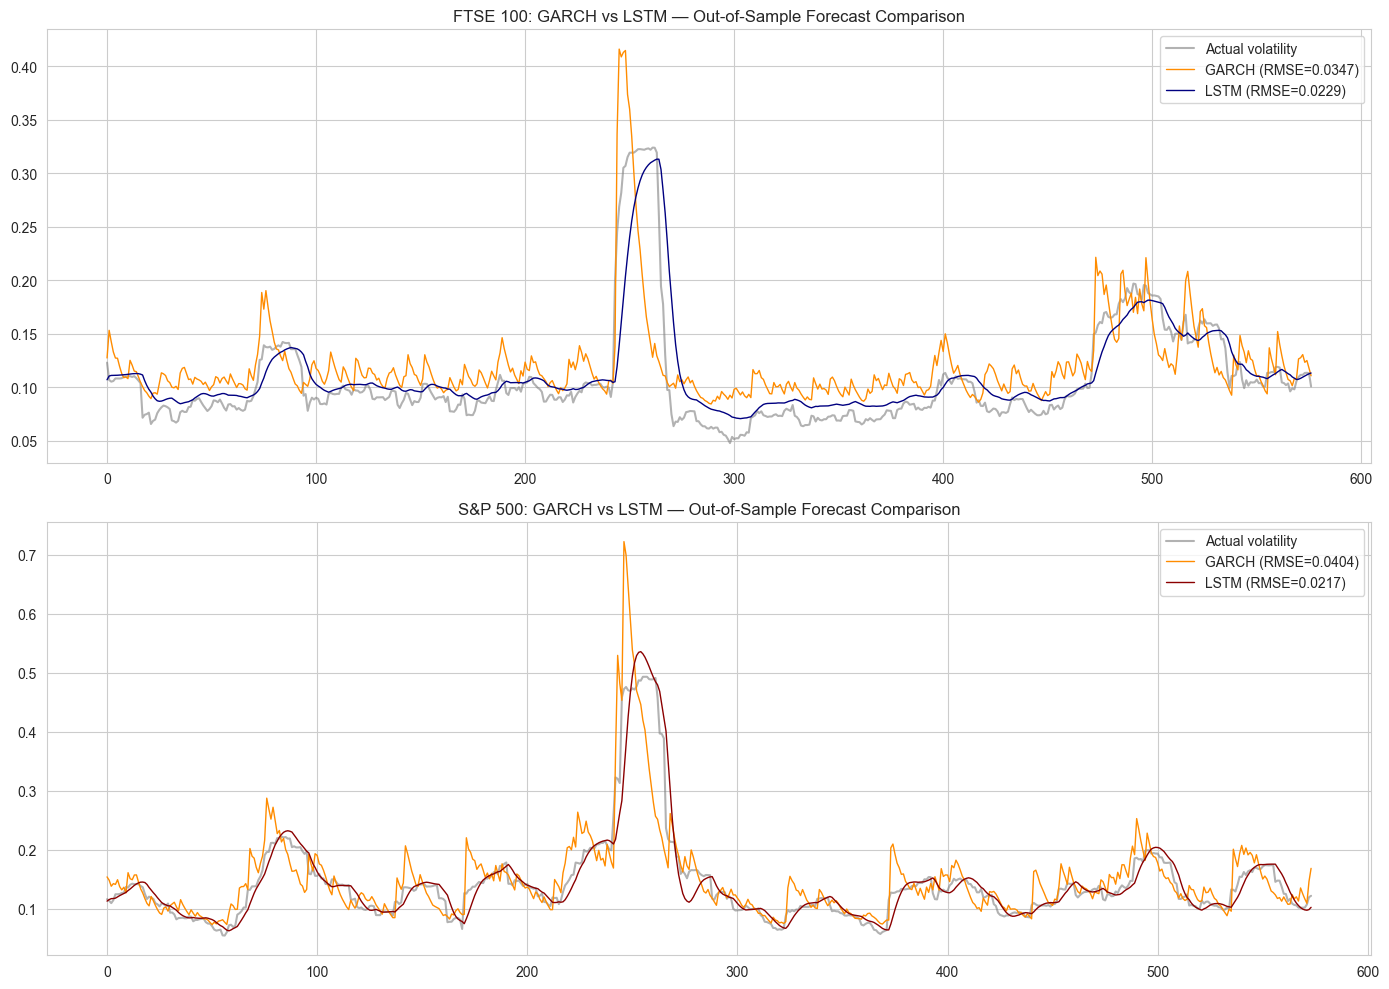

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(actual_garch_ftse, label='Actual volatility', color='gray', alpha=0.6, linewidth=1.5)
axes[0].plot(garch_forecast_ftse, label=f'GARCH (RMSE={rmse_garch_ftse:.4f})', color='darkorange', linewidth=1)
axes[0].plot(pred_ftse, label=f'LSTM (RMSE={rmse_lstm_ftse:.4f})', color='navy', linewidth=1)
axes[0].set_title('FTSE 100: GARCH vs LSTM — Out-of-Sample Forecast Comparison')
axes[0].legend()

axes[1].plot(actual_garch_sp500, label='Actual volatility', color='gray', alpha=0.6, linewidth=1.5)
axes[1].plot(garch_forecast_sp500, label=f'GARCH (RMSE={rmse_garch_sp500:.4f})', color='darkorange', linewidth=1)
axes[1].plot(pred_sp500, label=f'LSTM (RMSE={rmse_lstm_sp500:.4f})', color='darkred', linewidth=1)
axes[1].set_title('S&P 500: GARCH vs LSTM — Out-of-Sample Forecast Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# Add this after your comparison plot code, before plt.show()
import os
os.makedirs('assets', exist_ok=True)
plt.savefig('assets/garch_vs_lstm_comparison.png', dpi=150, bbox_inches='tight')

<Figure size 1200x600 with 0 Axes>